---
title: Coalescent conditioned on a derived variant
---

10.158574475644755


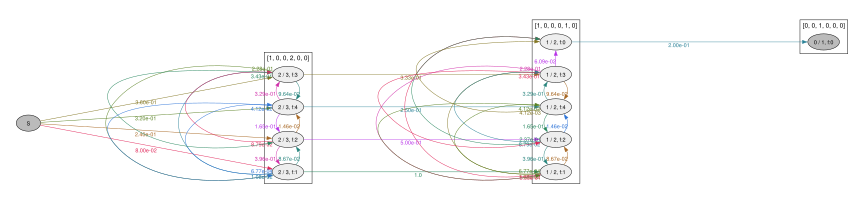

In [ ]:
from phasic import Graph, StateIndexer, Property
import numpy as np
from itertools import combinations_with_replacement
from functools import partial
all_pairs = partial(combinations_with_replacement, r=2)
from scipy.stats import binom
from scipy.stats import beta
from pprint import pprint

def coalescent_with_derived(state, indexer=None, N=None, s=0):
    transitions = []

    # callback params are always float
    N = int(N)

    # derived and total live lineages
    n_anc, n_der = 0, 0
    for i in range(indexer.lineages.state_length):
        p = indexer.lineages.i2p(i)
        if p.is_derived:
            n_der += state[i]
        else:
            n_anc += state[i]
    n_live = n_der + n_anc

    if n_live == 1:
        # absorbing state
        return []

    # pop derived freq
    freq = int(state[indexer.derived_freq])

    for i, j in all_pairs(range(indexer.lineages.state_length)):

        # props of lineage types at index i and j
        pi = indexer.lineages.i2p(i)
        pj = indexer.lineages.i2p(j)

        # both either anc or der
        same_ancestry = bool(pi.is_derived) == bool(pj.is_derived) and freq > 0

        # only coalesce derived and ancestral if derived is lost from population (implies the derived is now ancestral too)
        if not same_ancestry and freq > 0:
            continue

        same = int(i == j)
        if same and state[i] < 2:
            continue
        if not same and (state[i] < 1 or state[j] < 1):
            continue
        new = state.copy()
        new[i] -= 1
        new[j] -= 1
        is_derived = pi.is_derived if same_ancestry else 0 # can only be 0 if this is the final coalescence
        k = indexer.lineages.p2i(descendants=pi.descendants+pj.descendants, is_derived=is_derived)
        new[k] += 1

        # if n_live == 1 and new[indexer.derived_freq] > 0:
        #     continue

        pair_count = state[i] * (state[j] - same) / (1 + same)

        if pi.is_derived and pj.is_derived:
            allele_N = freq
        else:
            allele_N = N

        coef = [pair_count * (N/allele_N), 0, 0]
        transitions.append([new, coef])

        # transitions.append([new, [pair_count / allele_N]])

    # transitions to sister states with other derived population frequencies
    if n_live > 1 and freq > 0:

        # loop other freqs
        for f in range(N):

            # no self loops
            if f == freq:
                continue

            # der freq an only go to zero when a single der lineage remains
            if n_der > 1 and f == 0:
                continue

            new = state.copy()
            new[indexer.derived_freq] = f

            # # sampling_freq = freq/N

            # # NB: we subtract s because time is backwards
            # sampling_freq = freq/N * (1 - s) / (1 - s * freq/N)
            # binom_rate = binom.pmf(f, N, sampling_freq)

            # # binom_rate *= N # put freq change rates on same scale as coalescence rates
            # transitions.append([new, [binom_rate]])

            coef = [0, freq, f]
            transitions.append([new, coef])



    return transitions

pop_size = 5

n_samples = 3
n_derived = 2

indexer = StateIndexer(
    "derived_freq",
    lineages=[
        Property('descendants', min_value=1, max_value=n_samples),        
        Property('is_derived', min_value=0, max_value=1),        
        ],
)

# for i in range(indexer.state_length):
#     print(i, indexer.i2p(i))

ipv = []
k, n = n_derived, n_samples
a, b = 1 + k, 1 + (n - k)   # uniform prior
post = beta(a, b)

freqs = np.arange(1, pop_size, dtype=int)
rates = np.array([post.pdf(f/pop_size) for f in freqs])
rates = rates / np.sum(rates)

for i in range(len(freqs)):
    state = [0] * indexer.state_length
    state[indexer.lineages.props_to_index(descendants=1, is_derived=0)] = n_samples - n_derived
    state[indexer.lineages.props_to_index(descendants=1, is_derived=1)] = n_derived
    state[indexer.derived_freq] = freqs[i]
    ipv.append([state, rates[i]])

def label(vertex):
    state = vertex.state()
    anc, der = 0, 0
    for i in range(indexer.lineages.state_length):
        p = indexer.lineages.i2p(i)
        if p.is_derived:
            der += state[i]
        else:
            anc += state[i]
    return f'{der} / {anc+der}, f:{state[indexer.derived_freq]}'

def subgr(state):
    s = state.tolist()
    del s[indexer.derived_freq]
    return s


def weight_update(param, coef):
    N, s = param
    coal_rate_scalar, from_freq, to_freq = coef

    if coal_rate_scalar > 0:
        return coal_rate_scalar / N
    else:
        _s = - s # s is negative because time is backwards
        sampling_prob = from_freq/N * (1 + _s) / (1 + _s * from_freq/N)
        return binom.pmf(to_freq, N, sampling_prob)


graph = Graph(coalescent_with_derived, ipv=ipv, indexer=indexer, N=pop_size, s=0.5)

# NB: N must be fixed!
graph.update_weights([pop_size, 0.5], callback=weight_update)

print(graph.expectation())
graph.plot(
    by_state=subgr, 
           label_fmt=label,
            ranksep=7, nodesep=0.5, size=(12, 8),
            )    
# CAN I USE A CALLBACK WITH SVGD????


In [11]:
freq = 2
N = 10
s = 0.1
sampling_freq = freq/N
# sampling_freq = freq/N * (1 + s) / (1 + s * freq/N)
sampling_freq

#binom_rate = binom.pmf(f, N, sampling_freq)

0.2